In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

slope: 1.88, intercept: 5.13


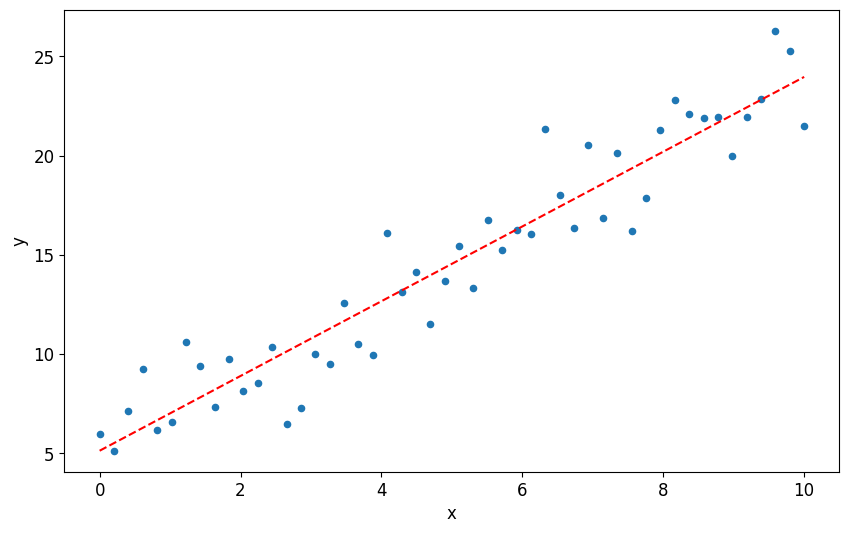

In [2]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

In [3]:
def fit_and_plot(x, y, ax):
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
  print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
  print(f"r: {r_value}")
  print(f"err: {std_err}")
  ax.plot(x, y, 'bo')
  x_linspace = np.linspace(min(x), max(x), 30)
  y_linreg = slope*x_linspace + intercept
  ax.plot(x_linspace, y_linreg, 'r-')

In [4]:
np.savetxt("dane_do_fit.txt", np.c_[x, y])

In [5]:
df = pd.read_csv("dane_do_fit.txt", delimiter=" ", header=None, names=["x", "y"])

In [6]:
df.head()

,x,y
0,0.000000,5.993428
1,0.204082,5.131635
2,0.408163,7.111704
3,0.612245,9.270550
4,0.816327,6.164346


slope: 1.88, intercept: 5.13
r: 0.9503548762459013
err: 0.08903837899142658


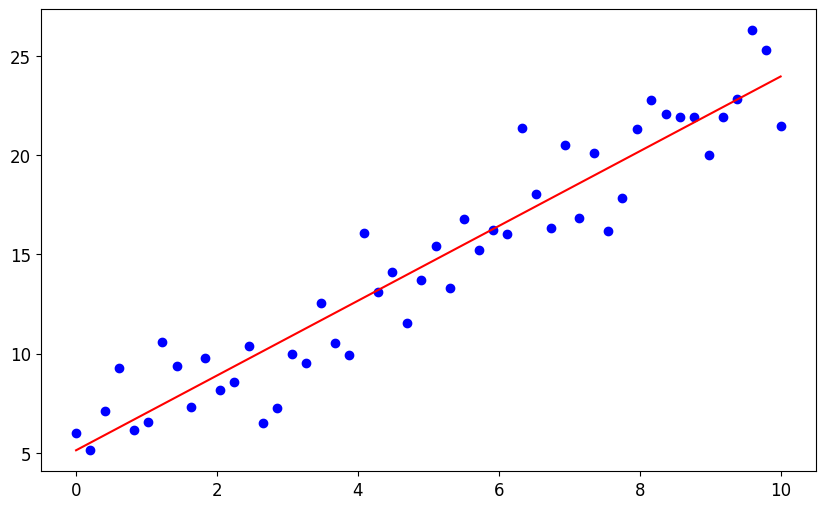

In [7]:
fig, ax = plt.subplots()
fit_and_plot(df['x'], df['y'], ax)

## Zadanie 1

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.





In [8]:
! head anscombe.csv

0,0,1,1,2,2,3,3
x,y,x,y,x,y,x,y
10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47
14.0,9.96,14.0,8.10,14.0,8.84,8.0,7.04
6.0,7.24,6.0,6.13,6.0,6.08,8.0,5.25
4.0,4.26,4.0,3.10,4.0,5.39,19.0,12.50


Wczytane dane Anscombe'a:
     x1    y1    x2    y2    x3     y3   x4    y4
0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
2  13.0  7.58  13.0  8.74  13.0  12.74  8.0  7.71
3   9.0  8.81   9.0  8.77   9.0   7.11  8.0  8.84
4  11.0  8.33  11.0  9.26  11.0   7.81  8.0  8.47


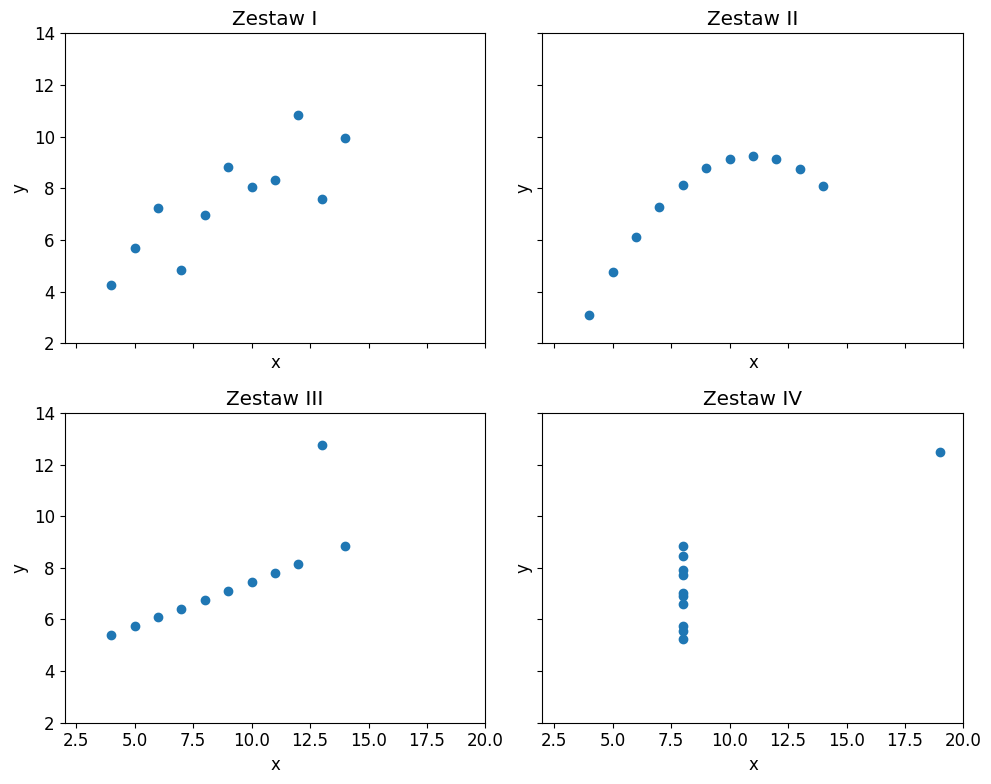

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df_anscombe = pd.read_csv('anscombe.csv', header=None, skiprows=2)

df_anscombe.columns = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']

print("Wczytane dane Anscombe:")
print(df_anscombe.head())

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

datasets = [
    ('I', df_anscombe['x1'], df_anscombe['y1']),
    ('II', df_anscombe['x2'], df_anscombe['y2']),
    ('III', df_anscombe['x3'], df_anscombe['y3']),
    ('IV', df_anscombe['x4'], df_anscombe['y4'])
]

for i, (title, x_data, y_data) in enumerate(datasets):
    ax = axes[i]
    ax.scatter(x_data, y_data)
    ax.set_title(f'Zestaw {title}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

plt.tight_layout()
plt.show()

## Zadanie 2

Przeprowadź eksploracyjną analizę danych (EDA) dla zbioru danych o domach `house_train.csv`

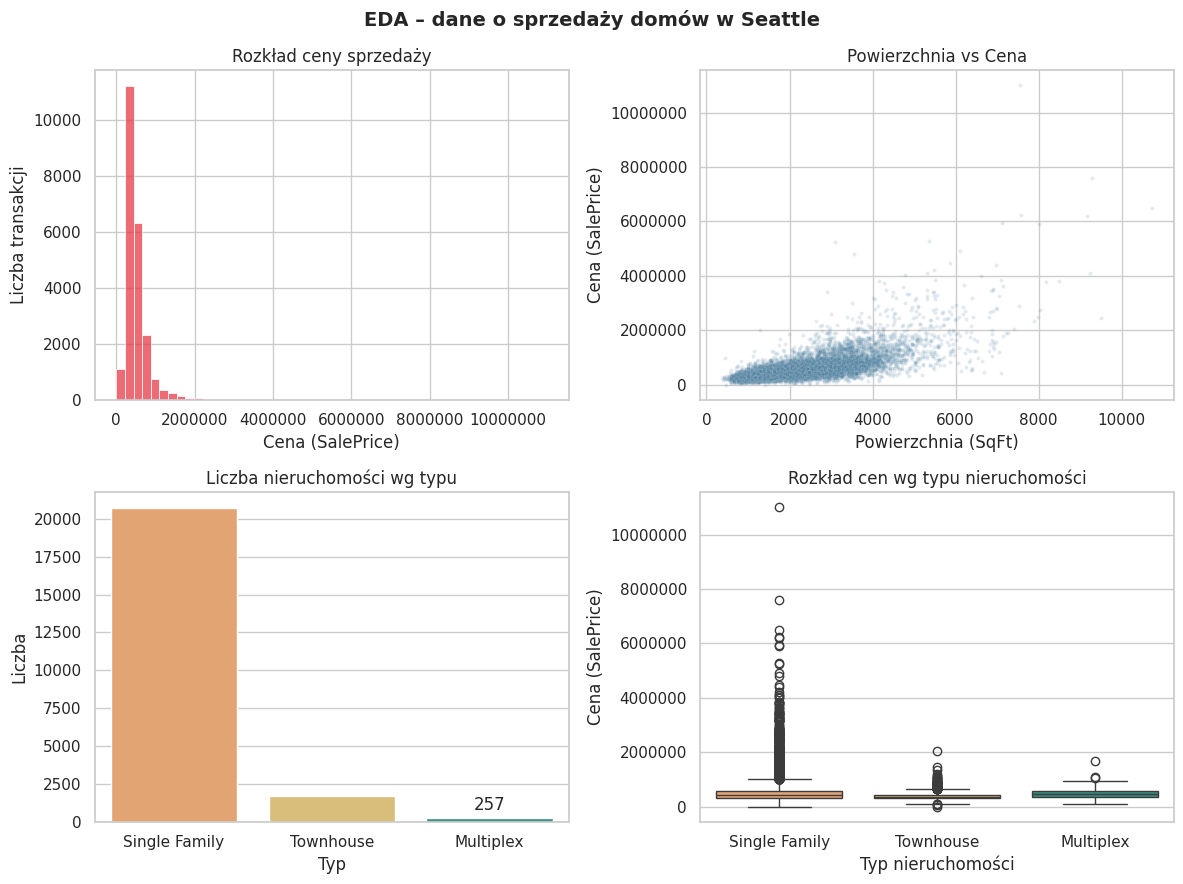

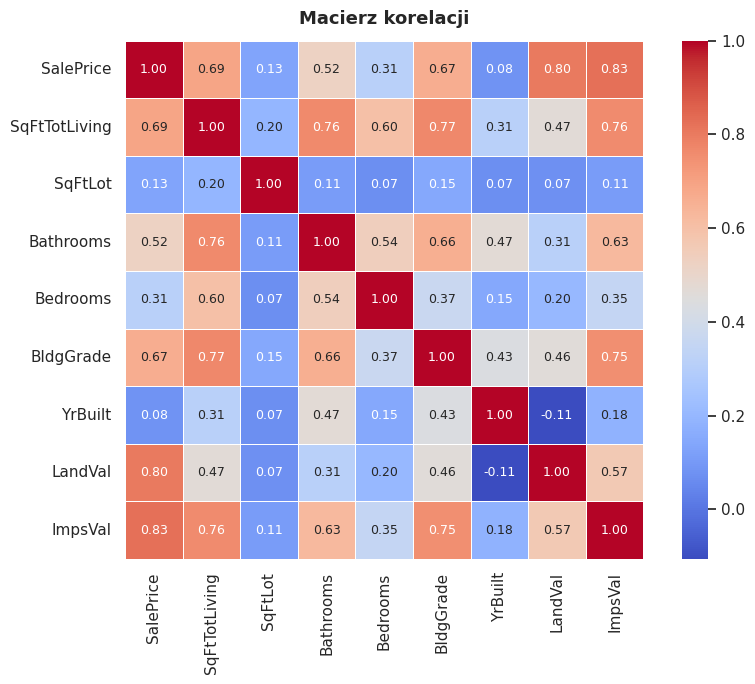

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("house_sales.csv", sep="\t")
df["DocumentDate"] = pd.to_datetime(df["DocumentDate"])
df["Year"] = df["DocumentDate"].dt.year

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("EDA – dane o sprzedaży domów w Seattle", fontsize=14, fontweight="bold")

sns.histplot(data=df, x="SalePrice", bins=50, color="#E63946", ax=axes[0, 0])
axes[0, 0].set(title="Rozkład ceny sprzedaży", xlabel="Cena (SalePrice)", ylabel="Liczba transakcji")
axes[0, 0].ticklabel_format(style="plain", axis="x")

sns.scatterplot(data=df, x="SqFtTotLiving", y="SalePrice", alpha=0.15, s=8, color="#457B9D", ax=axes[0, 1])
axes[0, 1].set(title="Powierzchnia vs Cena", xlabel="Powierzchnia (SqFt)", ylabel="Cena (SalePrice)")
axes[0, 1].ticklabel_format(style="plain", axis="y")

order = df["PropertyType"].value_counts().index
sns.countplot(data=df, x="PropertyType", hue="PropertyType", palette=["#2A9D8F", "#F4A261", "#E9C46A"], order=order, legend=False, ax=axes[1, 0])
axes[1, 0].bar_label(axes[1, 0].containers[0], padding=3)
axes[1, 0].set(title="Liczba nieruchomości wg typu", xlabel="Typ", ylabel="Liczba")

sns.boxplot(data=df, x="PropertyType", y="SalePrice", hue="PropertyType", palette=["#2A9D8F", "#F4A261", "#E9C46A"], order=order, legend=False, ax=axes[1, 1])
axes[1, 1].set(title="Rozkład cen wg typu nieruchomości", xlabel="Typ nieruchomości", ylabel="Cena (SalePrice)")
axes[1, 1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

num_cols = ["SalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade", "YrBuilt", "LandVal", "ImpsVal"]
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, annot_kws={"size": 9})
plt.title("Macierz korelacji", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()